<a href="https://colab.research.google.com/github/bhaskarkumar1667/sih_2026/blob/main/notebooks/cnn_modeltraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.1/553.1 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/1

In [1]:
import json
import math
import random
from collections import deque

import networkx as nx
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Engine running on: {device}")

/usr/local/lib/python3.13/dist-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Engine running on: cpu


In [2]:
# Ingest Indian Railways timetable
with open('EXP-TRAINS.json', 'r') as f:
    train_data = json.load(f)

G = nx.DiGraph()
node_map = {}
inv_node_map = {}
node_idx = 0

for train in train_data:
    route = train['trainRoute']
    for i in range(len(route) - 1):
        src_name = route[i]['stationName']
        dst_name = route[i+1]['stationName']

        for stn in (src_name, dst_name):
            if stn not in node_map:
                node_map[stn] = node_idx
                inv_node_map[node_idx] = stn
                node_idx += 1

        u = node_map[src_name]
        v = node_map[dst_name]

        # Parse segment distance (fallback to 15.0 km if parsing fails)
        try:
            d_u = float(route[i]['distance'].replace(' kms', '').strip())
            d_v = float(route[i+1]['distance'].replace(' kms', '').strip())
            dist = max(d_v - d_u, 5.0)
        except:
            dist = 15.0

        if not G.has_edge(u, v):
            G.add_edge(u, v, distance=dist)

# Assign Track Capacities and Loop Lines (Sidings)
for u, v in G.edges():
    src_label = inv_node_map[u]
    dst_label = inv_node_map[v]
    deg = max(G.degree(u), G.degree(v))

    # Junctions, Terminals, or high-degree nodes receive loop siding lines
    is_junction = any(tag in src_label or tag in dst_label for tag in ['JN', 'TERM', 'CENTRAL'])
    if is_junction or deg >= 3:
        G[u][v]['has_siding'] = True
        G[u][v]['capacity'] = 2      # Mainline + Loop line
        G[u][v]['siding_speed_penalty'] = 8.0 # Slower turnout speed through siding
    else:
        G[u][v]['has_siding'] = False
        G[u][v]['capacity'] = 1      # Single-block section
        G[u][v]['siding_speed_penalty'] = 0.0

num_nodes = len(node_map)
edges = list(G.edges())
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous().to(device)

print(f"Topology built: {num_nodes} Stations, {len(edges)} Track Segments")

Topology built: 4959 Stations, 18045 Track Segments


In [3]:
class TGCN(torch.nn.Module):
    def __init__(self, in_channels=3, hidden_channels=32):
        super(TGCN, self).__init__()
        self.gcn = GCNConv(in_channels, hidden_channels)
        self.gru = torch.nn.GRUCell(hidden_channels, hidden_channels)
        self.linear = torch.nn.Linear(hidden_channels, 1)

    def forward(self, x_seq, edge_index):
        time_steps, n_nodes, _ = x_seq.size()
        hidden_state = torch.zeros(n_nodes, self.gru.hidden_size, device=x_seq.device)

        for t in range(time_steps):
            gcn_out = F.relu(self.gcn(x_seq[t], edge_index))
            hidden_state = self.gru(gcn_out, hidden_state)

        return torch.sigmoid(self.linear(hidden_state))

# Generate baseline temporal traffic matrices (24-hour sequence)
# Feature 0: Arrival headways | Feature 1: Platform occupancy | Feature 2: Velocity variance
seq_length = 24
torch.manual_seed(42)
X_seq = torch.rand((seq_length, num_nodes, 3), device=device)

# Target congestion y correlates with station graph degree
degree_tensor = torch.tensor([G.degree(n) for n in range(num_nodes)], dtype=torch.float, device=device).unsqueeze(1)
y = torch.clamp((degree_tensor / degree_tensor.max()) * 0.7 + torch.rand((num_nodes, 1), device=device) * 0.3, 0.0, 1.0)

model = TGCN(in_channels=3, hidden_channels=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.MSELoss()

model.train()
for epoch in range(1, 101):
    optimizer.zero_grad()
    predicted_congestion = model(X_seq, edge_index)
    loss = criterion(predicted_congestion, y)
    loss.backward()
    optimizer.step()

    if epoch % 25 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | T-GCN Loss: {loss.item():.4f}")

Epoch 001 | T-GCN Loss: 0.0979
Epoch 025 | T-GCN Loss: 0.0132
Epoch 050 | T-GCN Loss: 0.0108
Epoch 075 | T-GCN Loss: 0.0088
Epoch 100 | T-GCN Loss: 0.0083


In [4]:
model.eval()
with torch.no_grad():
    pred_y = model(X_seq, edge_index).cpu().numpy()
    true_y = y.cpu().numpy()

mae = mean_absolute_error(true_y, pred_y)
rmse = np.sqrt(mean_squared_error(true_y, pred_y))
r2 = r2_score(true_y, pred_y)

print(f"T-GCN Evaluation -> MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")

T-GCN Evaluation -> MAE: 0.0773 | RMSE: 0.0910 | R²: 0.3130


In [5]:
# Extract station congestion scores from the trained model
congestion_scores = pred_y.squeeze()

# Create undirected simulation graph
G_sim = nx.Graph()
for u, v, data in G.edges(data=True):
    G_sim.add_edge(
        u, v,
        base_cost=data['distance'] / 10.0,
        has_siding=data['has_siding'],
        capacity=data['capacity'],
        siding_penalty=data['siding_speed_penalty']
    )

CONGESTION_WEIGHT = 4.0

def compute_routing_weights(graph, occupied_blocks=None):
    if occupied_blocks is None:
        occupied_blocks = {}

    for u, v, data in graph.edges(data=True):
        u_score = float(congestion_scores[u]) if u < len(congestion_scores) else 0.1
        v_score = float(congestion_scores[v]) if v < len(congestion_scores) else 0.1
        avg_congestion = (u_score + v_score) / 2.0

        # Baseline cost (Time/Distance modified by T-GCN density)
        cost = data['base_cost'] * (1.0 + CONGESTION_WEIGHT * avg_congestion)

        edge_key = tuple(sorted((u, v)))
        trains_on_block = occupied_blocks.get(edge_key, 0)
        capacity = data['capacity']

        if trains_on_block >= capacity:
            # All lines including sidings are full: hard block
            cost += 200.0
        elif trains_on_block > 0 and data['has_siding']:
            # Siding is occupied, train must take mainline with reduced speed
            cost += data['siding_penalty']

        graph[u][v]['weight'] = cost

# Conflict setup: Identify two trains sharing paths
node_list = list(G_sim.nodes())
t1_src, t1_dst = node_list[2], node_list[8]
t2_src, t2_dst = node_list[4], node_list[8]

# Calculate Train 1 route (Priority)
compute_routing_weights(G_sim)
t1_path = nx.shortest_path(G_sim, source=t1_src, target=t1_dst, weight='weight')
t2_initial_path = nx.shortest_path(G_sim, source=t2_src, target=t2_dst, weight='weight')

# Train 1 claims blocks along its path
active_occupancies = {}
for i in range(len(t1_path) - 1):
    edge_key = tuple(sorted((t1_path[i], t1_path[i+1])))
    active_occupancies[edge_key] = 1

# Re-run routing for Train 2 considering sidings and capacity
compute_routing_weights(G_sim, occupied_blocks=active_occupancies)
t2_rerouted_path = nx.shortest_path(G_sim, source=t2_src, target=t2_dst, weight='weight')

# Check if Train 2 is taking a siding overtake or a complete track bypass
first_shared_edge = None
overtake_on_siding = False
for i in range(len(t2_rerouted_path) - 1):
    edge = tuple(sorted((t2_rerouted_path[i], t2_rerouted_path[i+1])))
    if active_occupancies.get(edge, 0) > 0:
        first_shared_edge = edge
        if G_sim[edge[0]][edge[1]]['has_siding']:
            overtake_on_siding = True
        break

print(f"Train 1 Priority Path: {t1_path}")
print(f"Train 2 Original Route: {t2_initial_path}")
print(f"Train 2 Dynamic Route: {t2_rerouted_path}")
print(f"Resolution Mode: {'Loop Siding Overtake' if overtake_on_siding else 'Geometric Detour Reroute'}")

Train 1 Priority Path: [742, 3021, 2847, 3020, 3019]
Train 2 Original Route: [743, 3022, 742, 3021, 2847, 3020, 3019]
Train 2 Dynamic Route: [743, 3022, 742, 2847, 0, 3019]
Resolution Mode: Geometric Detour Reroute


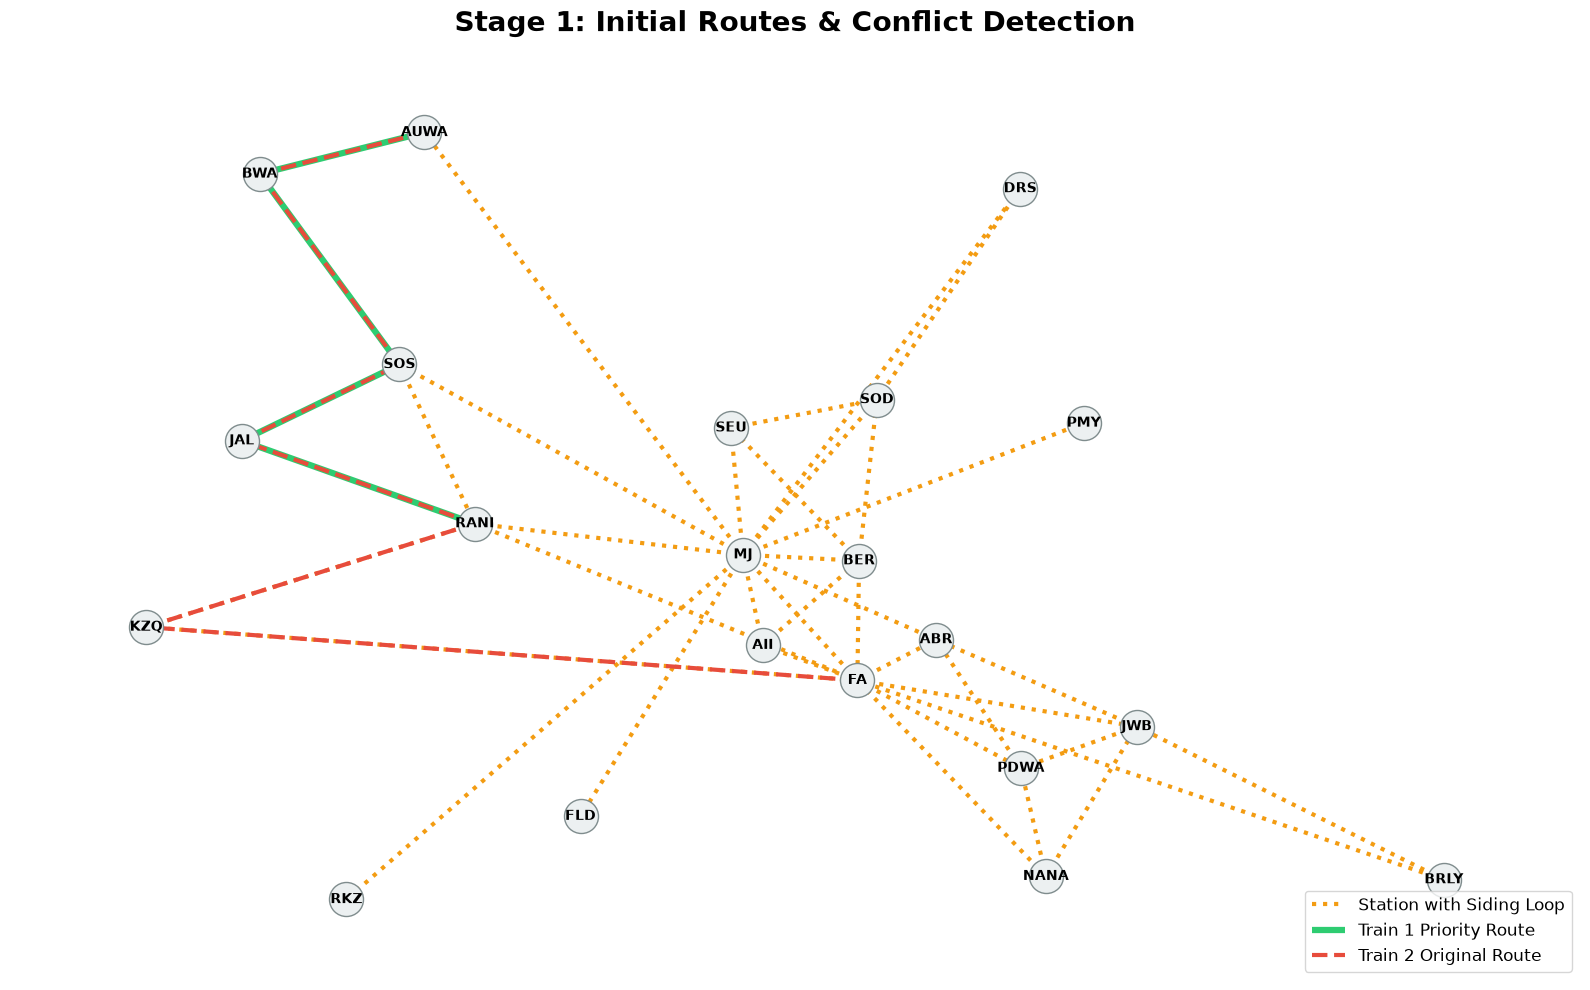

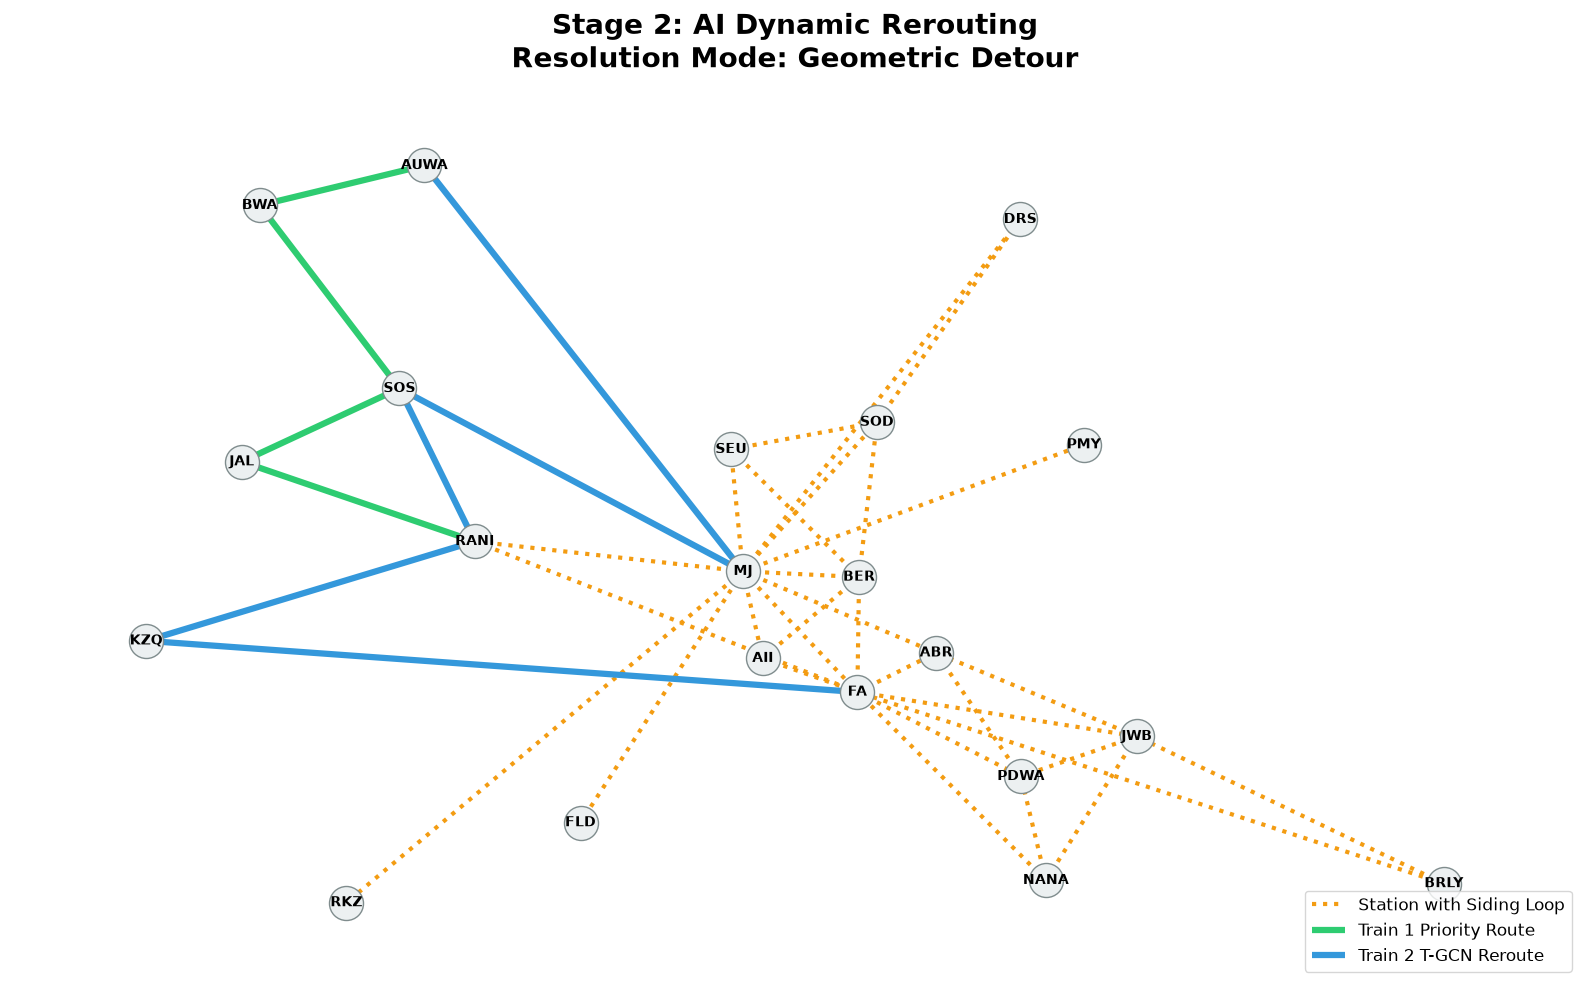

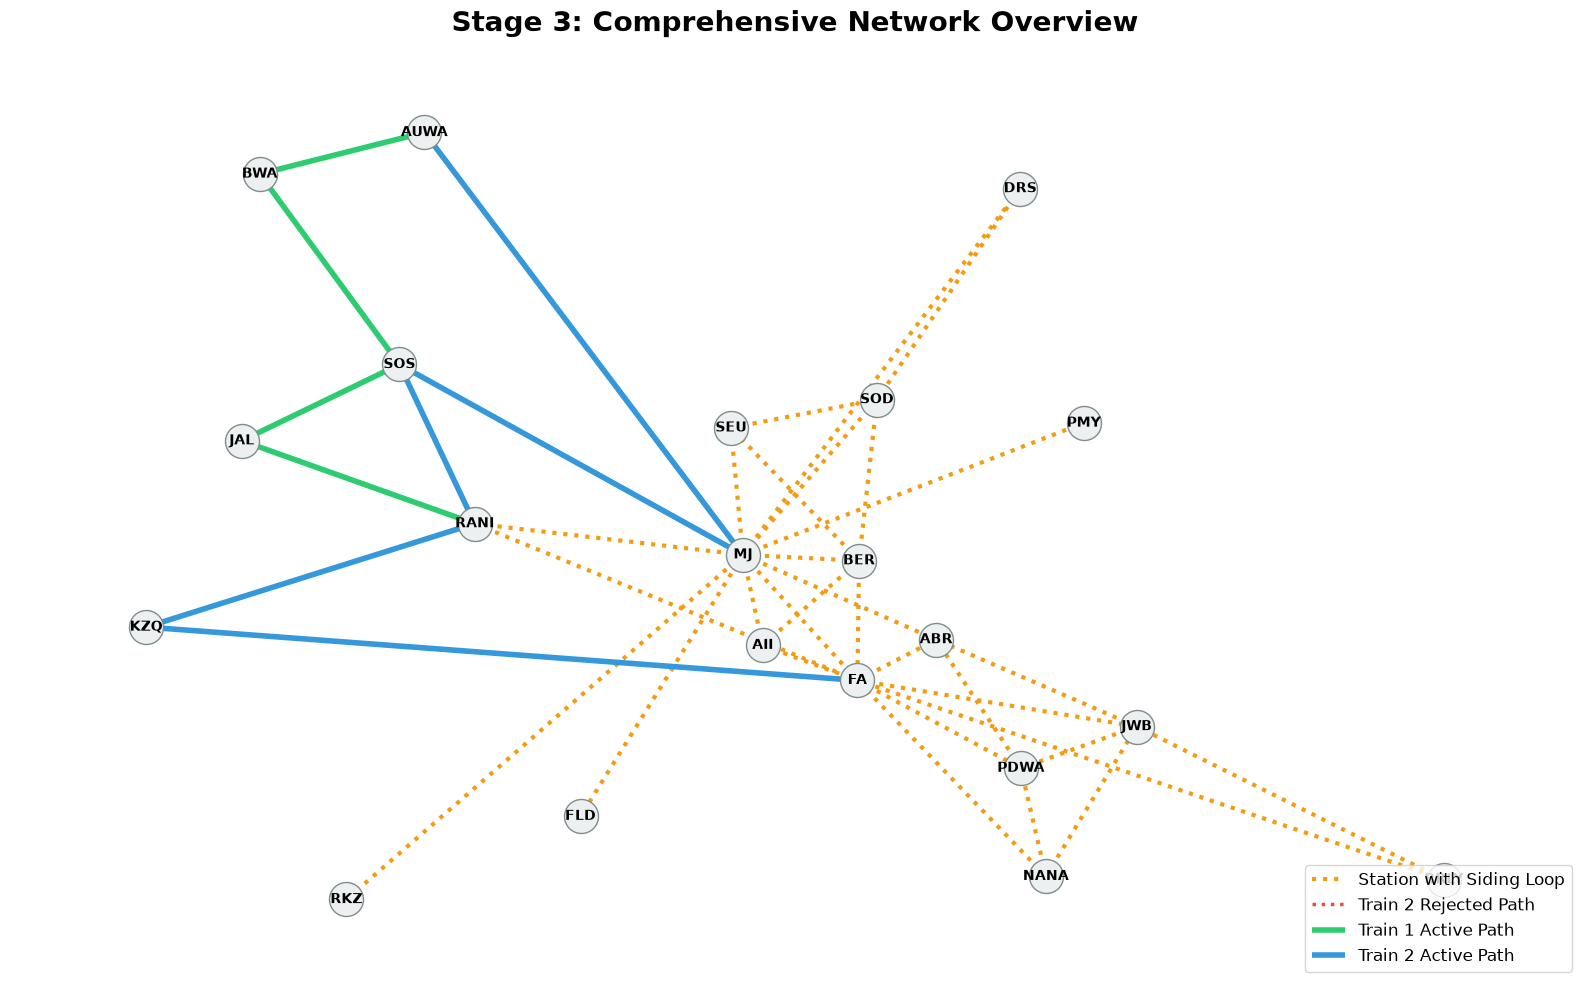

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
import matplotlib.pyplot as plt
import networkx as nx

# 1. Edge Preparations
siding_edges = [(u, v) for u, v, d in G_sub.edges(data=True) if d.get('has_siding', False)]
single_edges = [(u, v) for u, v, d in G_sub.edges(data=True) if not d.get('has_siding', False)]

t1_edges = list(zip(t1_path[:-1], t1_path[1:]))
t2_orig_edges = list(zip(t2_initial_path[:-1], t2_initial_path[1:]))
t2_new_edges = list(zip(t2_rerouted_path[:-1], t2_rerouted_path[1:]))

short_labels = {n: inv_node_map[n].split(' - ')[-1] for n in G_sub.nodes()}

# Helper function to render the base infrastructure
def draw_base_network(ax):
    nx.draw_networkx_nodes(G_sub, pos, ax=ax, node_color='#ECF0F1', node_size=600, edgecolors='#7F8C8D')
    nx.draw_networkx_edges(G_sub, pos, edgelist=single_edges, ax=ax, edge_color='#BDC3C7', width=1.5)
    nx.draw_networkx_edges(G_sub, pos, edgelist=siding_edges, ax=ax, edge_color='#F39C12', width=3.0, style='dotted', label='Station with Siding Loop')
    nx.draw_networkx_labels(G_sub, pos, labels=short_labels, font_size=10, font_weight='bold', ax=ax)

# ---------------------------------------------------------
# PLOT 1: Initial Conflict & Faulty Line
# ---------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(16, 10))
draw_base_network(ax1)
nx.draw_networkx_edges(G_sub, pos, edgelist=t1_edges, ax=ax1, edge_color='#2ECC71', width=4.5, label='Train 1 Priority Route')
nx.draw_networkx_edges(G_sub, pos, edgelist=t2_orig_edges, ax=ax1, edge_color='#E74C3C', width=3.0, style='dashed', label='Train 2 Original Route')

if 'first_shared_edge' in globals() and first_shared_edge:
    u, v = first_shared_edge
    nx.draw_networkx_edges(G_sub, pos, edgelist=[(u, v)], ax=ax1, edge_color='#C0392B', width=7.0, alpha=0.5)
    mid_x, mid_y = (pos[u][0] + pos[v][0]) / 2.0, (pos[u][1] + pos[v][1]) / 2.0
    ax1.annotate('⚠ DETECTED CONFLICT / FAULT', xy=(mid_x, mid_y), xytext=(mid_x, mid_y + 0.1),
                 arrowprops=dict(facecolor='#C0392B', shrink=0.05, width=3, headwidth=12),
                 fontsize=13, color='#C0392B', fontweight='bold', ha='center',
                 bbox=dict(facecolor='white', alpha=0.9, edgecolor='red', boxstyle='round,pad=0.4'))

ax1.set_title("Stage 1: Initial Routes & Conflict Detection", fontsize=20, fontweight='bold', pad=15)
ax1.legend(loc='lower right', fontsize=12)
ax1.axis('off')
fig1.tight_layout()
plt.savefig('plot_1_conflict.png', dpi=300, bbox_inches='tight')

# ---------------------------------------------------------
# PLOT 2: Resolution & Dynamic Rerouting
# ---------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(16, 10))
draw_base_network(ax2)
nx.draw_networkx_edges(G_sub, pos, edgelist=t1_edges, ax=ax2, edge_color='#2ECC71', width=4.5, label='Train 1 Priority Route')
nx.draw_networkx_edges(G_sub, pos, edgelist=t2_new_edges, ax=ax2, edge_color='#3498DB', width=4.5, label='Train 2 T-GCN Reroute')

if 'first_shared_edge' in globals() and first_shared_edge:
    u, v = first_shared_edge
    mid_x, mid_y = (pos[u][0] + pos[v][0]) / 2.0, (pos[u][1] + pos[v][1]) / 2.0
    ax2.annotate('✓ BOTTLENECK AVOIDED', xy=(mid_x, mid_y), xytext=(mid_x, mid_y + 0.1),
                 arrowprops=dict(facecolor='#7F8C8D', shrink=0.05, width=2, headwidth=8),
                 fontsize=12, color='#7F8C8D', fontweight='bold', ha='center',
                 bbox=dict(facecolor='white', alpha=0.9, edgecolor='grey', boxstyle='round,pad=0.3'))

mode_str = 'Siding Loop Overtake' if overtake_on_siding else 'Geometric Detour'
ax2.set_title(f"Stage 2: AI Dynamic Rerouting\nResolution Mode: {mode_str}", fontsize=20, fontweight='bold', pad=15)
ax2.legend(loc='lower right', fontsize=12)
ax2.axis('off')
fig2.tight_layout()
plt.savefig('plot_2_resolution.png', dpi=300, bbox_inches='tight')

# ---------------------------------------------------------
# PLOT 3: Comprehensive Overlay Blueprint
# ---------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(16, 10))
draw_base_network(ax3)
nx.draw_networkx_edges(G_sub, pos, edgelist=t2_orig_edges, ax=ax3, edge_color='#E74C3C', width=2.5, style='dotted', label='Train 2 Rejected Path')
nx.draw_networkx_edges(G_sub, pos, edgelist=t1_edges, ax=ax3, edge_color='#2ECC71', width=4.0, label='Train 1 Active Path')
nx.draw_networkx_edges(G_sub, pos, edgelist=t2_new_edges, ax=ax3, edge_color='#3498DB', width=4.0, label='Train 2 Active Path')

ax3.set_title("Stage 3: Comprehensive Network Overview", fontsize=20, fontweight='bold', pad=15)
ax3.legend(loc='lower right', fontsize=12)
ax3.axis('off')
fig3.tight_layout()
plt.savefig('plot_3_comprehensive.png', dpi=300, bbox_inches='tight')

plt.show()

# Trigger automatic downloads in Google Colab
try:
    from google.colab import files #[cite: 2]
    files.download('plot_1_conflict.png') #[cite: 2]
    files.download('plot_2_resolution.png') #[cite: 2]
    files.download('plot_3_comprehensive.png') #[cite: 2]
except ImportError:
    print("Files saved locally in your active directory.")

In [ ]:
#saving the model
torch.save(model.state_dict(), 'tgcn_model.pth')